In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 데이터 불러오기

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/한경-부트캠프/강의/기타/최종 프로젝트/코드파일/data/반려묘.csv")
df.head()

,metadata_breeding_food-amount,metadata_id_breed,metadata_id_sex,metadata_physical_weight,metadata_id_age,neutered,metadata_medical_diseaseName
0,0.5,KOR,Female,5.0,3.0,1,Normal
1,2.0,KOR,Male,6.0,2.0,1,Normal
2,1.0,KOR,Male,4.4,4.0,1,GAS
3,1.0,KOR,Female,3.2,1.5,0,DER/RES
4,1.0,KOR,Female,3.2,1.5,0,DER/RES


In [ ]:
import pandas as pd
import plotly.express as px

# 데이터프레임 생성
data = {'metadata_medical_diseaseName': ['정상', '호흡기/근육 질환', '치과 질환'],
        'count': [1323, 1019, 1016]}
df = pd.DataFrame(data)

# Plotly를 사용해 막대 그래프 시각화
fig = px.bar(df,
             x='metadata_medical_diseaseName',
             y='count',
             title='Distribution of metadata_medical_diseaseName',
             labels={'metadata_medical_diseaseName': 'Disease Name', 'count': 'Count'},
             text='count',  # 막대 위에 값 표시
             color='metadata_medical_diseaseName',  # 색상으로 구분
             color_discrete_sequence=px.colors.qualitative.Pastel)  # 색상 팔레트 설정

# 그래프 레이아웃 조정
fig.update_layout(
    xaxis_title="Disease Name",
    yaxis_title="Count",
    template="plotly_white",
    font=dict(size=14)
)

# 막대 위의 값 크기 조정
fig.update_traces(textfont_size=12, textposition='outside')

# 그래프 출력
fig.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3358 entries, 0 to 3357
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   metadata_breeding_food-amount  3358 non-null   float64
 1   metadata_id_breed              3358 non-null   object 
 2   metadata_id_sex                3358 non-null   object 
 3   metadata_physical_weight       3358 non-null   float64
 4   metadata_id_age                3358 non-null   float64
 5   neutered                       3358 non-null   int64  
 6   metadata_medical_diseaseName   3358 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 183.8+ KB


# 데이터 분포 확인(시각화 및 통계 수치 확인)

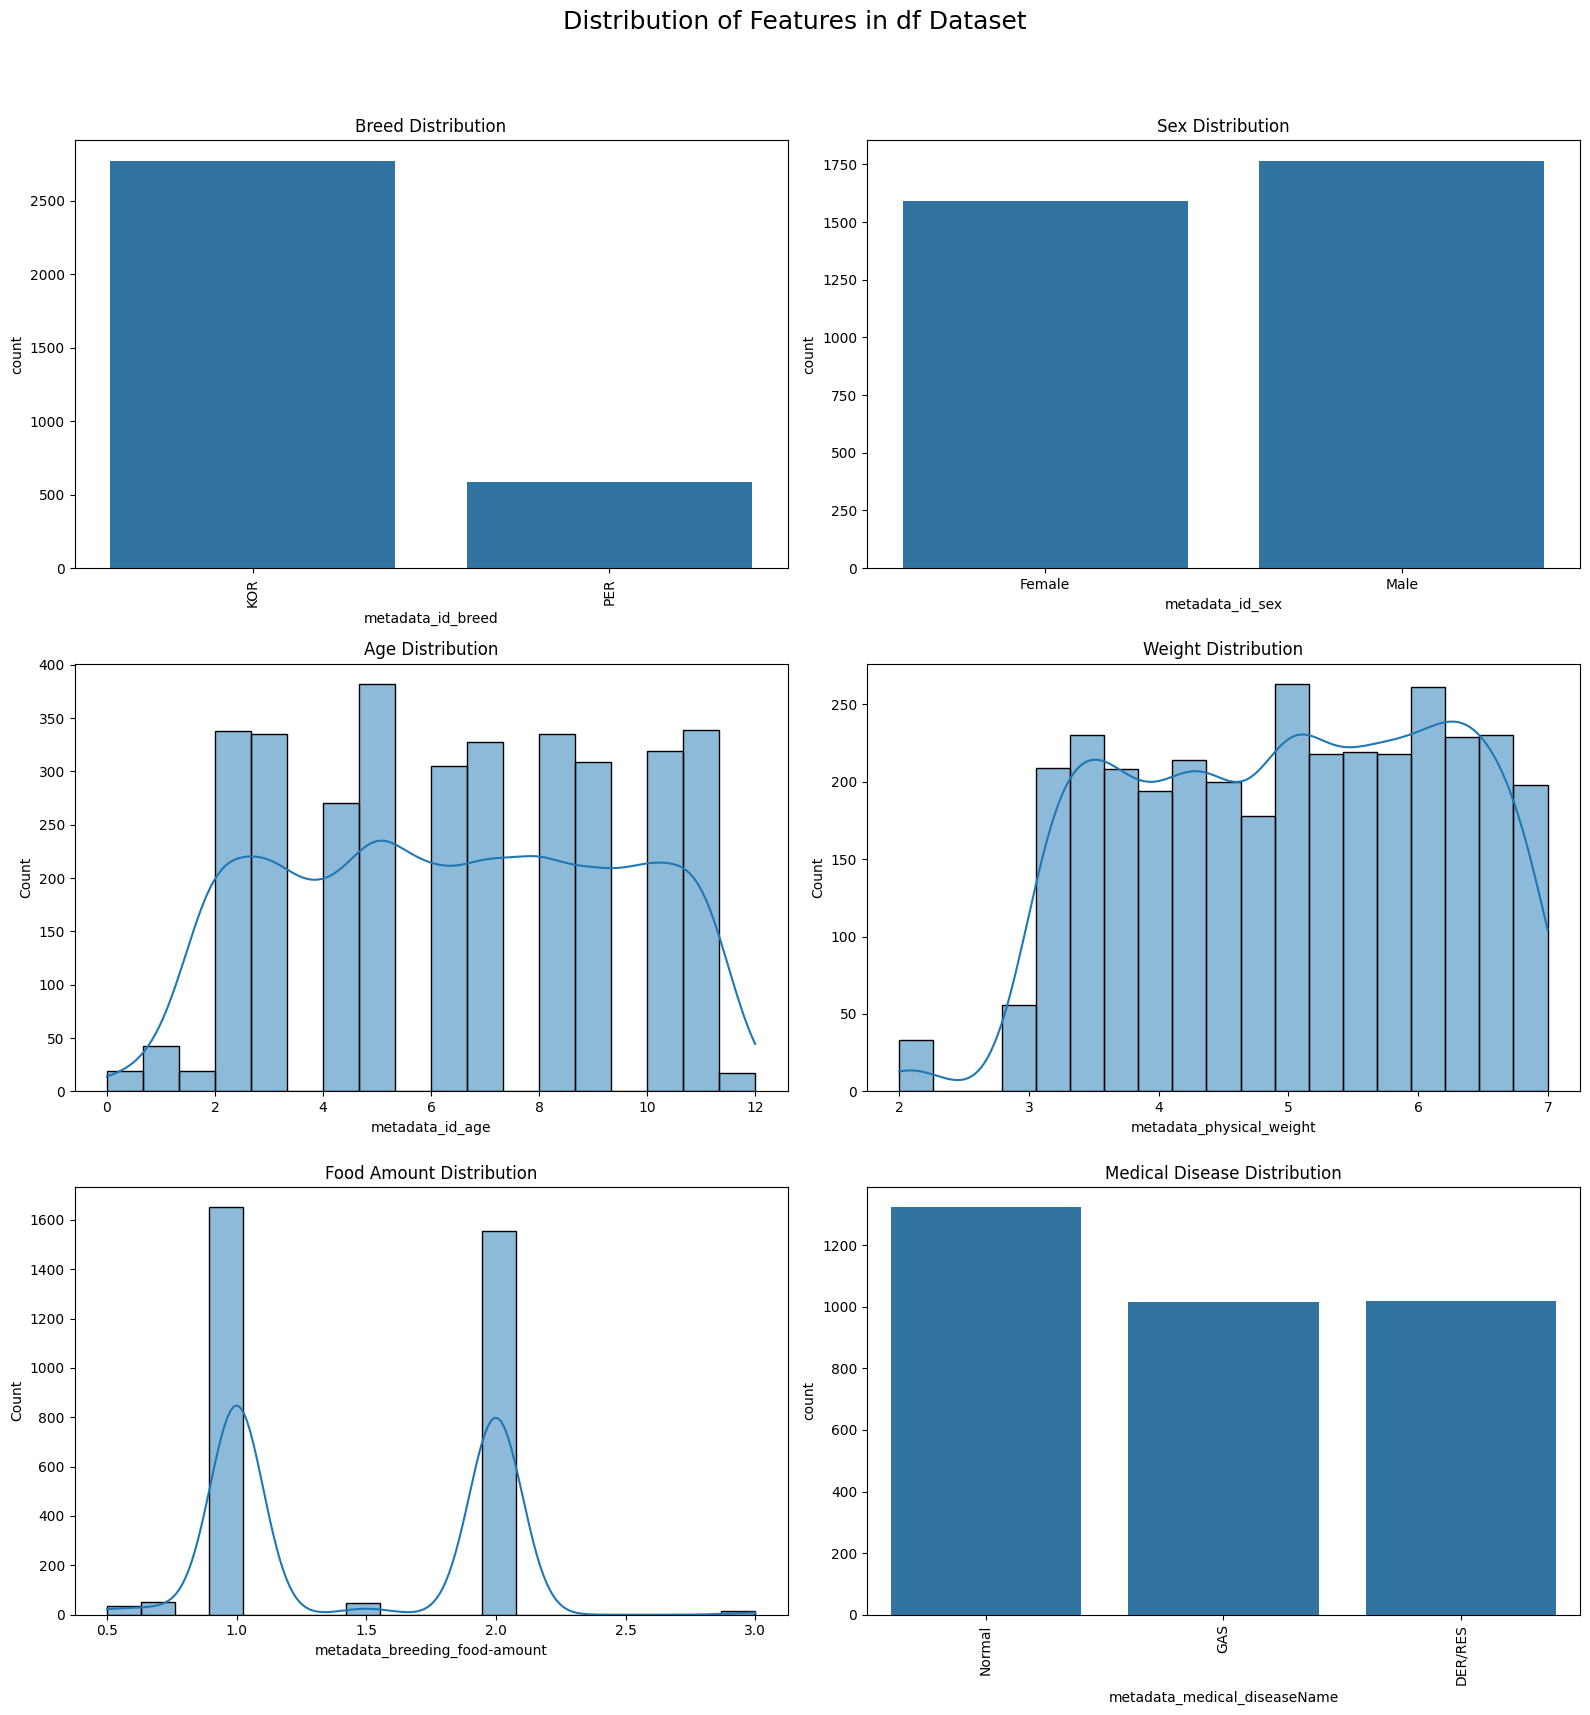

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 필요한 만큼의 서브플롯 생성
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Distribution of Features in df Dataset", fontsize=18)

sns.countplot(data=df, x='metadata_id_breed', ax=axes[0, 0])
axes[0, 0].set_title('Breed Distribution')
axes[0, 0].tick_params(axis='x', rotation=90)

sns.countplot(data=df, x='metadata_id_sex', ax=axes[0, 1])
axes[0, 1].set_title('Sex Distribution')

sns.histplot(df['metadata_id_age'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution')

sns.histplot(df['metadata_physical_weight'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Weight Distribution')

sns.histplot(df['metadata_breeding_food-amount'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Food Amount Distribution')

sns.countplot(data=df, x='metadata_medical_diseaseName', ax=axes[2, 1])
axes[2, 1].set_title('Medical Disease Distribution')
axes[2, 1].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 데이터 EDA

## 질병코드와 다른 열의 비교 시각화

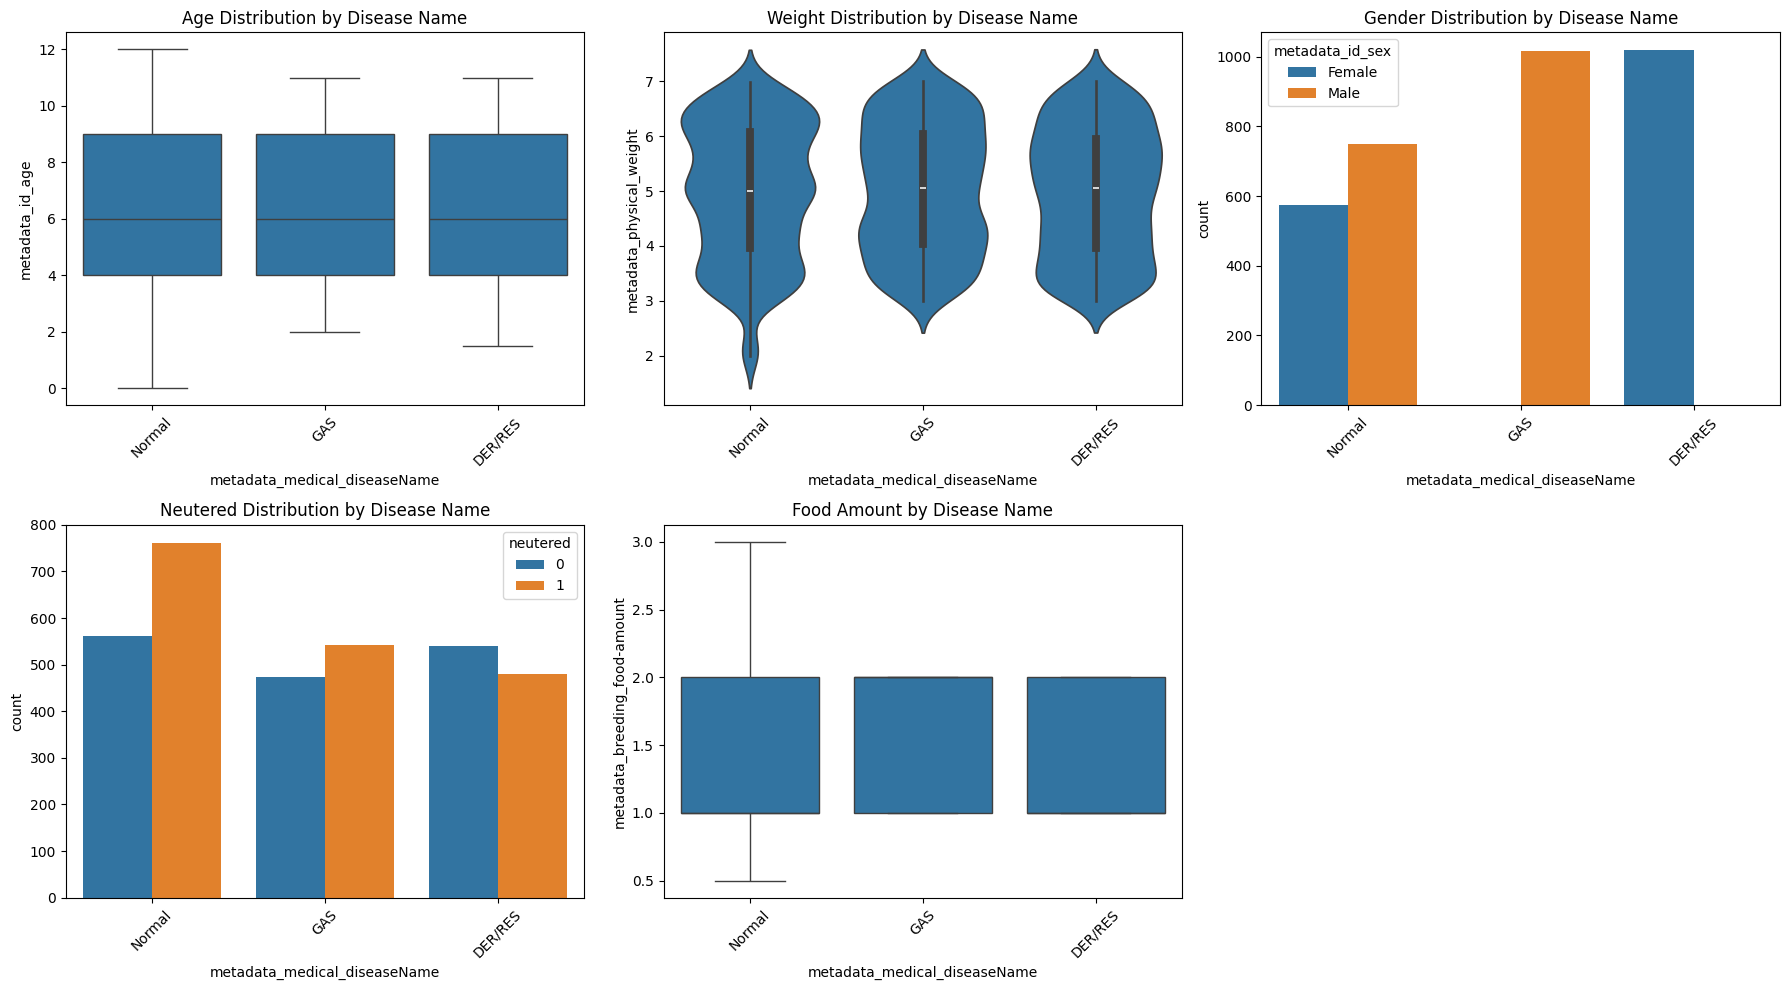

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Figure 크기 설정
plt.figure(figsize=(18, 10))

# 1. metadata_medical_diseaseName과 metadata_id_age의 박스플롯
plt.subplot(2, 3, 1)
sns.boxplot(x='metadata_medical_diseaseName', y='metadata_id_age', data=df)
plt.title('Age Distribution by Disease Name')
plt.xticks(rotation=45)

# 2. metadata_medical_diseaseName과 metadata_physical_weight의 바이올린 플롯
plt.subplot(2, 3, 2)
sns.violinplot(x='metadata_medical_diseaseName', y='metadata_physical_weight', data=df)
plt.title('Weight Distribution by Disease Name')
plt.xticks(rotation=45)

# 3. metadata_medical_diseaseName과 성별(metadata_id_sex) 간의 빈도 막대그래프
plt.subplot(2, 3, 3)
sns.countplot(x='metadata_medical_diseaseName', hue='metadata_id_sex', data=df)
plt.title('Gender Distribution by Disease Name')
plt.xticks(rotation=45)

# 4. metadata_medical_diseaseName과 neutered(중성화 여부) 간의 빈도 막대그래프
plt.subplot(2, 3, 4)
sns.countplot(x='metadata_medical_diseaseName', hue='neutered', data=df)
plt.title('Neutered Distribution by Disease Name')
plt.xticks(rotation=45)

# 5. metadata_medical_diseaseName과 metadata_breeding_food-amount 간의 박스플롯
plt.subplot(2, 3, 5)
sns.boxplot(x='metadata_medical_diseaseName', y='metadata_breeding_food-amount', data=df)
plt.title('Food Amount by Disease Name')
plt.xticks(rotation=45)

# 레이아웃 조정
plt.tight_layout()
plt.show()

## 각 변수별 질병의 유무와 유의미한 관계를 확인하기 위한 통계분석

- 수치형

In [ ]:
import pandas as pd
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# 새로운 열 'disease_status' 추가: 'Normal' 또는 'Disease'로 구분
df['disease_status'] = df['metadata_medical_diseaseName'].apply(lambda x: 'Normal' if x == 'Normal' else 'Disease')

# 그룹화
groups = ['Normal', 'Disease']
numeric_columns = ['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']

# 각 그룹의 데이터를 나누기
group_data = {group: df[df['disease_status'] == group] for group in groups}

# 정규성 검정과 통계 분석
for col in numeric_columns:
    # 각 그룹의 정규성 검정
    group_shapiro = {group: shapiro(group_data[group][col])[1] for group in groups}

    # 두 그룹 간 비교
    if all(p > 0.05 for p in group_shapiro.values()):  # 두 그룹 모두 정규성을 따른다면
        t_stat, p_value = ttest_ind(group_data['Normal'][col], group_data['Disease'][col])
        test_result = "T-test"
    else:  # 정규성을 따르지 않으면
        u_stat, p_value = mannwhitneyu(group_data['Normal'][col], group_data['Disease'][col])
        test_result = "Mann-Whitney U"

    # 출력
    print(f"Column: {col}")
    print(f"Shapiro-Wilk p-values: {group_shapiro}")
    print(f"Test: {test_result}")
    print(f"Statistic: {t_stat if test_result == 'T-test' else u_stat}, p-value: {p_value}")
    print("-" * 50)

Column: metadata_id_age
Shapiro-Wilk p-values: {'Normal': 2.267542551568065e-19, 'Disease': 6.392612011563812e-29}
Test: Mann-Whitney U
Statistic: 1316374.0, p-value: 0.27578872501964147
--------------------------------------------------
Column: metadata_physical_weight
Shapiro-Wilk p-values: {'Normal': 2.8956799758064408e-18, 'Disease': 8.874047251748735e-25}
Test: Mann-Whitney U
Statistic: 1335782.0, p-value: 0.7056162212317598
--------------------------------------------------
Column: metadata_breeding_food-amount
Shapiro-Wilk p-values: {'Normal': 9.804668839438853e-40, 'Disease': 2.3254869641649436e-54}
Test: Mann-Whitney U
Statistic: 1198978.5, p-value: 1.329312592518407e-09
--------------------------------------------------


# 나이 (metadata_id_age)
- Shapiro-Wilk 정규성 검정:
  - Normal 그룹 p-value = 2.27e-19
- Disease 그룹 p-value = 6.39e-29
- 두 그룹 모두 p-value가 매우 낮아 정규분포를 따르지 않음.

- Mann-Whitney U 검정:
  - 검정 통계량: U = 1,316,374.0
  - p-value = 0.276
- 해석: p-value가 0.05보다 크므로, 두 그룹 간 나이 분포에 유의미한 차이가 없음.

# 2. 몸무게 (metadata_physical_weight)
- Shapiro-Wilk 정규성 검정:
  - Normal 그룹 p-value = 2.90e-18
  - Disease 그룹 p-value = 8.87e-25
- 두 그룹 모두 p-value가 매우 낮아 정규분포를 따르지 않음.

- Mann-Whitney U 검정:
- 검정 통계량: U = 1,335,782.0
  - p-value = 0.706
- 해석: p-value가 0.05보다 크므로, 두 그룹 간 몸무게 분포에 유의미한 차이가 없음.

# 3. 식사량 (metadata_breeding_food-amount)
- Shapiro-Wilk 정규성 검정:
  - Normal 그룹 p-value = 9.80e-40
  - Disease 그룹 p-value = 2.33e-54
- 두 그룹 모두 p-value가 매우 낮아 정규분포를 따르지 않음.

- Mann-Whitney U 검정:
  - 검정 통계량: U = 1,198,978.5
  - p-value = 1.33e-09
- 해석: p-value가 0.05보다 작으므로, 두 그룹 간 식사량 분포에 유의미한 차이가 있음.

# 결론 요약
- 나이 (metadata_id_age): 두 그룹 간 유의미한 차이가 없음.
- 몸무게 (metadata_physical_weight): 두 그룹 간 유의미한 차이가 없음.
- 식사량 (metadata_breeding_food-amount):두 그룹 간 유의미한 차이가 있음.


- 범주형

분석 변수: metadata_id_breed vs metadata_medical_diseaseName

[교차표]
metadata_medical_diseaseName  DER/RES   GAS  Normal
metadata_id_breed                                  
KOR                              1019  1016     739
PER                                 0     0     584

[카이제곱 검정]
Chi-Square Statistic: 1087.41
P-value: 0.00000

[Cramér's V]
Cramér's V: 0.57


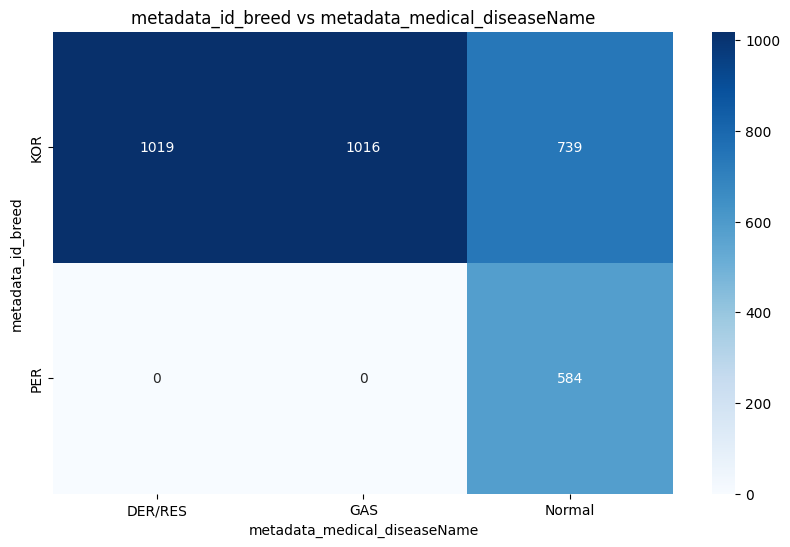

분석 변수: metadata_id_sex vs metadata_medical_diseaseName

[교차표]
metadata_medical_diseaseName  DER/RES   GAS  Normal
metadata_id_sex                                    
Female                           1019     0     573
Male                                0  1016     750

[카이제곱 검정]
Chi-Square Statistic: 2055.18
P-value: 0.00000

[Cramér's V]
Cramér's V: 0.78


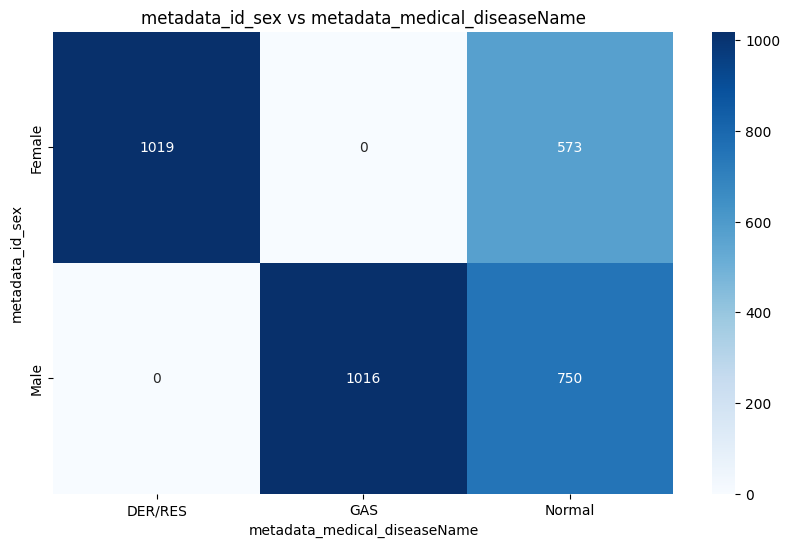

분석 변수: neutered vs metadata_medical_diseaseName

[교차표]
metadata_medical_diseaseName  DER/RES  GAS  Normal
neutered                                          
0                                 540  473     561
1                                 479  543     762

[카이제곱 검정]
Chi-Square Statistic: 25.98
P-value: 0.00000

[Cramér's V]
Cramér's V: 0.09


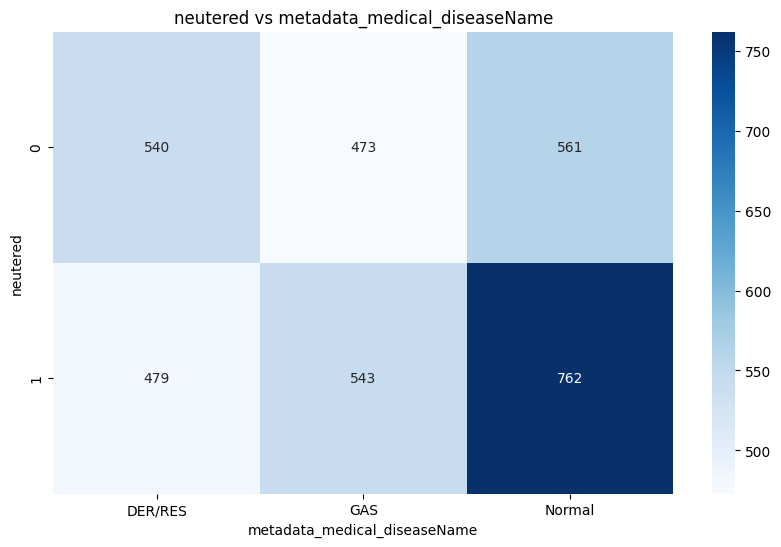


[분석 결과 요약]
            Variable         Chi2        P-value  Cramér's V
0  metadata_id_breed  1087.405816  7.461519e-237    0.569057
1    metadata_id_sex  2055.182264   0.000000e+00    0.782321
2           neutered    25.980660   2.282293e-06    0.087960


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터프레임에서 범주형 컬럼만 추출
categorical_columns = ['metadata_id_breed', 'metadata_id_sex', 'neutered']

# 결과를 저장할 리스트
results = []

# 카이제곱 검정, 교차표 분석, Cramér's V를 각 변수에 대해 실행
for col in categorical_columns:
    print(f"분석 변수: {col} vs metadata_medical_diseaseName")

    # 1. 교차표 생성
    crosstab = pd.crosstab(df[col], df['metadata_medical_diseaseName'])
    print("\n[교차표]")
    print(crosstab)

    # 2. 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print("\n[카이제곱 검정]")
    print(f"Chi-Square Statistic: {chi2:.2f}")
    print(f"P-value: {p:.5f}")

    # 3. Cramér의 V 계산
    n = crosstab.sum().sum()  # 전체 관측치 수
    cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
    print("\n[Cramér's V]")
    print(f"Cramér's V: {cramers_v:.2f}")

    # 결과 저장
    results.append({
        "Variable": col,
        "Chi2": chi2,
        "P-value": p,
        "Cramér's V": cramers_v
    })

    # 4. 교차표 시각화
    plt.figure(figsize=(10, 6))
    sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{col} vs metadata_medical_diseaseName")
    plt.ylabel(col)
    plt.xlabel('metadata_medical_diseaseName')
    plt.show()

# 결과 요약 출력
results_df = pd.DataFrame(results)
print("\n[분석 결과 요약]")
print(results_df)

# 1. metadata_id_breed vs metadata_medical_diseaseName
- 교차표: KOR (한국) 품종의 경우 DER/RES와 GAS가 비슷한 수치를 보이고, Normal은 적은 수치를 보임.
- PER (페르시안) 품종의 경우 Normal만 존재.
- 카이제곱 검정:
  - Chi-Square Statistic: 1087.41
  - p-value: 0.00000 (유의미한 차이가 있음)
  - Cramér's V: 0.57 (상당한 효과 크기)
- 해석: 품종에 따라 질병 유형(DER/RES, GAS, Normal) 간에 유의미한 차이가 있으며, 품종과 질병 간의 관계가 강하게 나타남.

# 2. metadata_id_sex vs metadata_medical_diseaseName
- 교차표: Female은 주로 DER/RES와 Normal에 분포.
- Male은 주로 GAS와 Normal에 분포.
- 카이제곱 검정:
  - Chi-Square Statistic: 2055.18
  - p-value: 0.00000 (유의미한 차이가 있음)
  - Cramér's V: 0.78 (매우 강한 효과 크기)
- 해석: 성별에 따른 질병 유형 분포에 강한 유의미한 차이가 있으며, 성별과 질병 간의 관계가 매우 강함.

# 3. neutered vs metadata_medical_diseaseName
- 교차표: Neutered (중성화된) 개와 중성화되지 않은 개들 간의 질병 분포 차이가 있음.
- 카이제곱 검정:
  - Chi-Square Statistic: 25.98
  - p-value: 0.00000 (유의미한 차이가 있음)
  - Cramér's V: 0.09 (약한 효과 크기)
- 해석: 중성화 여부에 따른 질병 유형에 차이가 있지만, 효과 크기는 상대적으로 작음.

# 결론
- **metadata_id_breed (품종)**과 **metadata_id_sex (성별)**은 질병 유형과 강한 관계가 있으며, 품종과 성별에 따른 질병 분포에 유의미한 차이가 존재함.

- Cramér's V 값이 높아, 품종과 성별은 질병 발생에 큰 영향을 미치는 변수들임.
- **neutered (중성화 여부)**는 질병 유형과의 관계가 유의미하지만, 효과 크기는 상대적으로 작은 편임.

# 각 열별로 어떤 식으로 영향을 미칠까?
  - 로지스틱 회귀 분석으로 알아보자

In [ ]:
df.drop(columns=['disease_status'], inplace=True)

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

df_copy = df.copy()

# Label Encoding
le = LabelEncoder()
df_copy['metadata_id_breed'] = le.fit_transform(df_copy['metadata_id_breed'])
df_copy['metadata_id_sex'] = le.fit_transform(df_copy['metadata_id_sex'])

# StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_copy[['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']] = scaler.fit_transform(df_copy[['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']])

# 독립 변수(X)와 종속 변수(y) 분리
X = df_copy.drop(['metadata_medical_diseaseName'], axis=1)
y = df_copy['metadata_medical_diseaseName']

# 상수항 추가
X = sm.add_constant(X)

# 다항 로지스틱 회귀 모델 생성 및 학습
mnlogit_model = sm.MNLogit(y, X)
result = mnlogit_model.fit(maxiter=1000, method='lbfgs', pgtol=1e-6)

# 결과 출력
print(result.summary())

                               MNLogit Regression Results                               
Dep. Variable:     metadata_medical_diseaseName   No. Observations:                 3358
Model:                                  MNLogit   Df Residuals:                     3344
Method:                                     MLE   Df Model:                           12
Date:                          Thu, 21 Nov 2024   Pseudo R-squ.:                  0.5760
Time:                                  02:36:18   Log-Likelihood:                -1552.6
converged:                                 True   LL-Null:                       -3662.1
Covariance Type:                      nonrobust   LLR p-value:                     0.000
metadata_medical_diseaseName=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              1.5514      0.103     15.009      0.000       1.349    

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산
X_vif = X.drop('const', axis=1)  # 상수항 제외
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# VIF 값 출력
print(vif_data)

                        Variable       VIF
0  metadata_breeding_food-amount  1.009231
1              metadata_id_breed  1.129857
2                metadata_id_sex  1.490324
3       metadata_physical_weight  1.015822
4                metadata_id_age  1.004764
5                       neutered  1.496347


# 모델 요약
- Pseudo R-squared: 0.5760
  - 이 값은 모델이 데이터를 얼마나 잘 설명하는지를 나타냅니다. 0.5760은 꽤 괜찮은 적합도를 의미하지만, 완벽한 모델은 아닙니다.

- Log-Likelihood: -1552.6
  - Log-Likelihood는 모델이 데이터를 얼마나 잘 설명하는지 평가하는 값으로, 이 값이 커질수록 모델이 데이터를 잘 설명한다고 할 수 있습니다. 값이 -3662.1에서 -1552.6으로 줄어든 것은 모델이 일부 성능 향상을 보였다는 것을 의미합니다.

- LLR p-value: 0.000
  - 모델의 유의성 검정을 나타내며, 0.000으로 나타난 것은 모델이 통계적으로 매우 유의하다는 것을 의미합니다. 즉, 이 모델은 단순한 우연이 아니라 중요한 관계를 포착하고 있다는 뜻.

# metadata_medical_diseaseName = 1 (질병 1)

- metadata_breeding_food-amount: 0.1906 (p-value = 0.007)
  - metadata_breeding_food-amount는 질병 1의 발생과 유의미한 양의 상관관계를 가집니다. 이 변수의 값이 커질수록 질병 1에 걸릴 확률이 증가한다고 해석할 수 있습니다.

- metadata_id_breed: -21.1705 (p-value = 0.986)
  - metadata_id_breed는 매우 큰 계수를 가지며, p-value가 0.986으로 나타났습니다. 이는 해당 변수에 대한 모델의 유의미한 영향을 찾지 못했음을 나타냅니다. 즉, 품종 정보는 질병 1과 관련이 없을 가능성이 큽니다.

- metadata_physical_weight: 0.1497 (p-value = 0.033)
  - 체중(metadata_physical_weight)이 질병 1 발생과 유의미한 양의 상관관계를 가집니다. 체중이 증가할수록 질병 1에 걸릴 확률이 증가하는 경향이 있습니다.

- metadata_id_age: 0.0608 (p-value = 0.376)
  - 나이(metadata_id_age)는 질병 1에 대한 유의미한 영향을 미치지 않는 것으로 나타났습니다. p-value가 0.376으로 통계적으로 유의미하지 않습니다.

- neutered: -0.4113 (p-value = 0.003)
  - 중성화 여부(neutered)는 질병 1과 유의미한 음의 관계가 있습니다. 중성화된 고양이는 질병 1에 걸릴 확률이 낮아지는 경향이 있습니다.

# metadata_medical_diseaseName = 2 (질병 2)

- metadata_breeding_food-amount: 0.2132 (p-value = 0.000)
  - metadata_breeding_food-amount는 질병 2의 발생과 유의미한 양의 상관관계를 가집니다. 이 값이 커질수록 질병 2에 걸릴 확률이 증가한다고 해석할 수 있습니다.

- metadata_physical_weight: -0.1958 (p-value = 0.001)
  - 체중은 질병 2의 발생과 음의 상관관계를 가집니다. 체중이 증가할수록 질병 2에 걸릴 확률이 감소하는 경향이 있습니다.

- metadata_id_age: 0.1697 (p-value = 0.003)
  - 나이는 질병 2와 양의 상관관계를 가집니다. 나이가 많을수록 질병 2에 걸릴 확률이 증가하는 경향이 있습니다.

- neutered: -0.4091 (p-value = 0.001)
  - 중성화 여부는 질병 2에 대해서도 음의 관계를 보입니다. 중성화된 고양이는 질병 2에 걸릴 확률이 낮아지는 경향이 있습니다.

# 주요 결론
- breeding_food-amount는 두 질병에서 모두 유의미한 양의 상관관계를 보입니다.
- metadata_id_breed와 metadata_id_sex는 모델에서 유의미한 영향을 주지 않았습니다.
- physical_weight는 질병 1과 질병 2에서 서로 다른 방향으로 영향을 미칩니다.
- neutered는 두 질병 모두에 대해 음의 관계가 있어, 중성화된 고양이는 두 질병에 걸릴 확률이 낮아집니다.

# 각 질병코드별로 군집 분석을 통한 특징 확인
  - K-프로토타입스

In [ ]:
!pip install kmodes

- pca

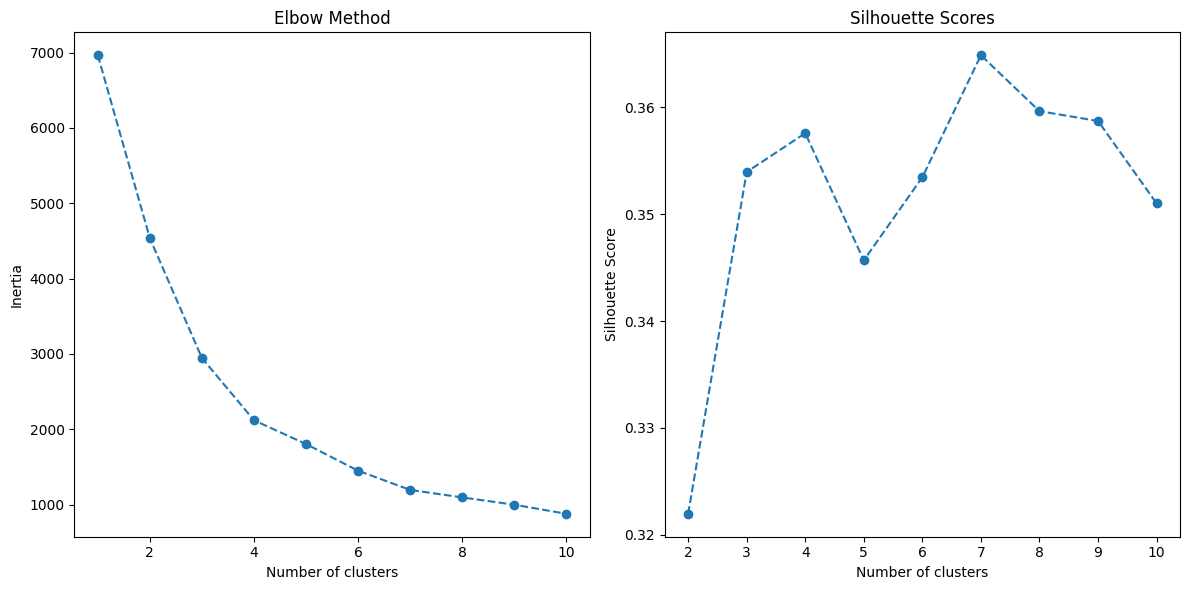

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 원본 데이터프레임을 건드리지 않도록 복사본 생성
df_copy = df.copy()

# 1. 레이블 인코딩 (Label Encoding)
label_encoder = LabelEncoder()

# 범주형 변수에 대해 레이블 인코딩 적용
df_copy['metadata_id_breed'] = label_encoder.fit_transform(df_copy['metadata_id_breed'])
df_copy['metadata_id_sex'] = label_encoder.fit_transform(df_copy['metadata_id_sex'])
df_copy['metadata_medical_diseaseName'] = label_encoder.fit_transform(df_copy['metadata_medical_diseaseName'])

# 2. 수치형 데이터만 선택
numeric_data = df_copy[['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']]

# 3. 데이터 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# 4. PCA 수행
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 5. 엘보우 메서드
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_result)
    inertia.append(kmeans.inertia_)

# 6. 실루엣 계수
silhouette_scores = []
for k in range(2, 11):  # 실루엣 계수는 최소 2개 이상의 클러스터가 필요
    kmeans = KMeans(n_clusters=k)
    cluster_labels = kmeans.fit_predict(pca_result)
    silhouette_avg = silhouette_score(pca_result, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# 시각화: 엘보우 메서드
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

# 시각화: 실루엣 계수
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from kmodes.kprototypes import KPrototypes

kdata = df.copy()

# 범주형 변수 인덱스 지정
categorical_columns = ['metadata_id_breed', 'metadata_id_sex', 'neutered', 'metadata_medical_diseaseName']

# K-프로토타입스를 사용할 수 있도록 범주형 데이터와 수치형 데이터를 나누기
categorical_data = kdata[categorical_columns].apply(lambda x: x.astype('category'))
numerical_data = kdata.drop(categorical_columns, axis=1)

# 범주형 데이터와 수치형 데이터를 모두 포함하는 데이터셋으로 변환
categorical_data_encoded = categorical_data.apply(lambda x: x.cat.codes)

# 수치형 데이터와 범주형 데이터 결합
final_data = pd.concat([numerical_data, categorical_data_encoded], axis=1)

# K-프로토타입스 모델 생성 및 군집화
kproto = KPrototypes(n_clusters=4, init='Cao', verbose=2)
clusters = kproto.fit_predict(final_data, categorical=[1, 2, 3, 6])  # 범주형 데이터 인덱스

# 결과 출력
kdata['Cluster'] = clusters
print(kdata)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 178, ncost: 2936.2162319195236
Run: 1, iteration: 2/100, moves: 0, ncost: 2936.2162319195236
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 153, ncost: 3222.8439984329484
Run: 2, iteration: 2/100, moves: 107, ncost: 3185.3904555128474
Run: 2, iteration: 3/100, moves: 0, ncost: 3185.3904555128474
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 3, iteration: 1/100, moves: 784, ncost: 3082.149075850244
Run: 3, iteration: 2/100, moves: 168, ncost: 3054.5653477284513
Run: 3, iteration: 3/100, moves: 5, ncost: 3054.519389501126
Run: 3, iteration: 4/100, moves: 0, ncost: 3054.519389501126
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 4, iteration: 1/100, moves: 213, n

## 각 클러스터별 수치형 통계량 확인

- Cluster 0
  - 나이(metadata_id_age): 평균은 6.35, 표준편차는 3.16으로 비교적 넓은 분포를 가집니다. 중앙값은 6.0으로 중간 정도의 나이인 개체들이 포함됩니다.
  - 신체 무게(metadata_physical_weight): 평균은 4.76kg, 표준편차는 1.28kg으로, 무게 분포가 좁습니다. 중앙값은 4.86kg입니다.
  - 사료 섭취량(metadata_breeding_food-amount): 평균은 0.98 단위, 표준편차는 0.11 단위로 매우 좁은 분포를 보이며, 중앙값은 1.0 단위로 낮습니다.

- Cluster 1
  - 나이: 평균은 6.45, 표준편차는 2.87로 분포가 약간 좁습니다. 중앙값은 6.0입니다.
  - 신체 무게: 평균은 5.01kg, 표준편차는 1.12kg로 Cluster 0보다 약간 무겁습니다. 중앙값은 5.06kg입니다.
  - 사료 섭취량: 평균은 2.02 단위, 표준편차는 0.14 단위로 섭취량이 다른 클러스터보다 높습니다. 중앙값은 2.0 단위입니다.

- Cluster 2
  - 나이: 평균은 6.45, 표준편차는 2.94로 Cluster 1과 유사합니다. 중앙값은 7.0으로 나이가 약간 많은 개체들이 포함됩니다.
  - 신체 무게: 평균은 5.18kg, 표준편차는 1.13kg으로 무게가 가장 무겁습니다. 중앙값은 5.20kg입니다.
  - 사료 섭취량: 평균은 1.47 단위, 표준편차는 0.50 단위로 중간 수준입니다. 중앙값은 1.0 단위입니다.

- Cluster 3
  - 나이: 평균은 6.30, 표준편차는 3.01로 나이 분포는 평균 수준입니다. 중앙값은 6.0입니다.
  - 신체 무게: 평균은 5.01kg, 표준편차는 1.18kg으로 Cluster 1과 유사합니다. 중앙값은 5.05kg입니다.
  - 사료 섭취량: 평균은 1.47 단위, 표준편차는 0.52 단위로 Cluster 2와 비슷하며, 중앙값은 1.0 단위입니다.

## 요약 및 비교
- 나이(metadata_id_age):
  - 모든 클러스터의 평균 나이는 약 6.3~6.4세로 큰 차이가 없습니다.
  - Cluster 2는 중앙값이 7.0으로 나이가 약간 많은 경향을 보입니다.

- 신체 무게(metadata_physical_weight):
  - Cluster 2가 가장 무거운 평균 5.18kg을 보이며, Cluster 0이 가장 가벼운 평균 4.76kg을 보입니다.

- 사료 섭취량(metadata_breeding_food-amount):
  - Cluster 1은 평균 2.02 단위로 가장 많은 사료를 섭취합니다.
  - Cluster 0은 평균 0.98 단위로 가장 적은 사료를 섭취합니다.

## 결론
- Cluster 0은 상대적으로 가벼운 체중과 적은 사료 섭취량을 가진 개체들이 많습니다.
- Cluster 1은 무게는 평균 수준이지만, 사료 섭취량이 가장 많은 클러스터입니다.
- Cluster 2는 나이가 조금 많고, 무게도 가장 무겁습니다.
- Cluster 3은 Cluster 1과 유사하지만, 사료 섭취량은 Cluster 2와 비슷합니다.







In [ ]:
# 각 클러스터별 수치형 변수에 대한 통계량 계산
cluster_stats = kdata.groupby('Cluster').agg({
    'metadata_id_age': ['mean', 'std', 'median'],
    'metadata_physical_weight': ['mean', 'std', 'median'],
    'metadata_breeding_food-amount': ['mean', 'std', 'median'],
})

print(cluster_stats)

        metadata_id_age                  metadata_physical_weight            \
                   mean       std median                     mean       std   
Cluster                                                                       
0              6.350764  3.157446    6.0                 4.756513  1.282835   
1              6.447820  2.870943    6.0                 5.006480  1.120403   
2              6.445122  2.940065    7.0                 5.176619  1.129096   
3              6.298956  3.013377    6.0                 5.012258  1.178815   

                  metadata_breeding_food-amount                   
           median                          mean       std median  
Cluster                                                           
0        4.855812                      0.984783  0.105443    1.0  
1        5.062320                      2.021136  0.143933    2.0  
2        5.201326                      1.467226  0.497226    1.0  
3        5.048329                      1.468

## 2. 범주형 변수의 빈도 분포 확인 종합적 해석

## 1. metadata_id_sex (성별)
- 클러스터별 성별 분포
  - Cluster 0: Female(암컷) 851마리로 100% 암컷으로 구성.
  - Cluster 1: Female 741마리, Male(수컷) 16마리로 거의 암컷 위주.
  - Cluster 2: Male 984마리로 100% 수컷으로 구성.
  - Cluster 3: Male 766마리로 100% 수컷으로 구성.

### 해석
- Cluster 0과 Cluster 1은 대부분 암컷이며, 특히 Cluster 0은 전적으로 암컷만 포함.
- Cluster 2와 Cluster 3은 전적으로 수컷만 포함.
- 성별 분포가 클러스터별로 명확히 구분됨.

## 2. neutered (중성화 여부)
- 클러스터별 중성화 분포:
  - Cluster 0: 중성화(1) 446마리, 비중성화(0) 405마리로 비슷한 비율.
  - Cluster 1: 비중성화(0) 403마리, 중성화(1) 354마리로 비중성화가 더 많음.
  - Cluster 2: 중성화(1) 984마리로 100% 중성화.
  - Cluster 3: 비중성화(0) 766마리로 100% 비중성화.

### 해석
- Cluster 2는 100% 중성화, Cluster 3은 100% 비중성화로 완전히 대조적.
- Cluster 0과 Cluster 1은 중성화와 비중성화 비율이 비슷하지만, 비중성화 비율이 약간 더 높음.

## 3. metadata_medical_diseaseName (질병 이름)
- 클러스터별 질병 분포
  - Cluster 0: DER/RES(피부/호흡기 질환) 512마리, Normal(정상) 339마리로 질병 비율이 높음.
  - Cluster 1: DER/RES 507마리, Normal 250마리로 질병 비율이 높음.
  - Cluster 2: GAS(소화기 질환) 543마리, Normal 441마리로 질병 비율이 높음.
  - Cluster 3: GAS 473마리, Normal 293마리로 질병 비율이 높음.

### 해석
- Cluster 0과 Cluster 1은 DER/RES(피부/호흡기 질환)가 주요 질병.
- Cluster 2와 Cluster 3은 GAS(소화기 질환)가 주요 질병.
- 모든 클러스터에서 질병이 있는 개체가 정상 개체보다 많음.

# 종합 해석

- 품종 및 성별
  - 모든 클러스터에서 KOR(코리안 쇼트헤어)가 대부분이며, PER(페르시안 고양이)는 소수.
  - Cluster 0과 Cluster 1은 암컷 위주, Cluster 2와 Cluster 3은 수컷 위주로 성별이 분명히 나뉘어 있음.

- 중성화 여부
  - Cluster 2는 중성화된 개체로만, Cluster 3은 비중성화된 개체로만 구성됨.
  - Cluster 0과 Cluster 1은 중성화 여부가 혼재되어 있지만, 비중성화가 약간 더 많음.

- 질병 이름
  - Cluster 0과 Cluster 1: 피부 및 호흡기 질환(DER/RES)이 주요 질병.
  - Cluster 2와 Cluster 3: 소화기 질환(GAS)이 주요 질병.

In [ ]:
# 각 클러스터별 범주형 변수의 빈도 수 확인
for col in categorical_columns:
    print(f"Cluster-wise distribution for {col}:")
    print(kdata.groupby('Cluster')[col].value_counts())
    print()

Cluster-wise distribution for metadata_id_breed:
Cluster  metadata_id_breed
0        KOR                  672
         PER                  179
1        KOR                  638
         PER                  119
2        KOR                  841
         PER                  143
3        KOR                  623
         PER                  143
Name: count, dtype: int64

Cluster-wise distribution for metadata_id_sex:
Cluster  metadata_id_sex
0        Female             851
1        Female             741
         Male                16
2        Male               984
3        Male               766
Name: count, dtype: int64

Cluster-wise distribution for neutered:
Cluster  neutered
0        1           446
         0           405
1        0           403
         1           354
2        1           984
3        0           766
Name: count, dtype: int64

Cluster-wise distribution for metadata_medical_diseaseName:
Cluster  metadata_medical_diseaseName
0        DER/RES                 

## 3. 클러스터별로 특징적인 범주형 변수 확인 종합 해석

## Cluster 0
- DER/RES: 60.16%
- Normal: 39.84%

- 해석
  - 이 클러스터에서 DER/RES(피부 및 호흡기 질환)의 비율이 높음. 약 **60%**가 질병을 가지고 있고, **40%**는 정상 개체임.
  - DER/RES가 이 클러스터의 주요 건강 문제.

## Cluster 1
- DER/RES: 66.97%
- Normal: 33.03%

- 해석
  - DER/RES 비율이 약 **67%**로, Cluster 0보다 질병 비율이 더 높음.
  - 이 클러스터는 피부 및 호흡기 질환이 매우 지배적이며, 정상 개체 비율이 가장 낮음(33%).
## Cluster 2
- GAS: 55.18%
- Normal: 44.82%

- 해석
- 이 클러스터는 GAS(소화기 질환)가 주요 건강 문제로, 비율이 약 55%.
- 질병 비율이 높은 편이지만, 정상 개체 비율(44.82%)도 비교적 높음.
- Cluster 0과 Cluster 1에 비해 정상 개체 비율이 더 높은 점이 특징.

## Cluster 3
- GAS: 61.75%
- Normal: 38.25%
- 해석
  - 이 클러스터 역시 GAS가 주요 질병으로, 비율이 약 62%.
  - Cluster 2보다 소화기 질환의 비율이 더 높으며, 정상 개체 비율이 낮음(38.25%).


## 종합 분석

- 질병 비율 비교
  - DER/RES는 Cluster 0과 Cluster 1에서 주요 문제로 나타나며, Cluster 1에서 비율이 더 높음(67%).
  - GAS는 Cluster 2와 Cluster 3에서 주요 문제로 나타나며, Cluster 3에서 비율이 더 높음(62%).

- 정상 개체 비율
  - Cluster 2는 **44.82%**로 정상 개체 비율이 가장 높음.
  - Cluster 1은 정상 개체 비율이 가장 낮음(33%).

- 클러스터 특성
  - Cluster 0과 Cluster 1은 피부 및 호흡기 질환(DER/RES) 중심의 클러스터.
  - Cluster 2와 Cluster 3은 소화기 질환(GAS) 중심의 클러스터.





In [ ]:
# 각 클러스터별로 'metadata_medical_diseaseName'의 분포 확인
disease_distribution = kdata.groupby('Cluster')['metadata_medical_diseaseName'].value_counts(normalize=True)
print(disease_distribution)

Cluster  metadata_medical_diseaseName
0        DER/RES                         0.601645
         Normal                          0.398355
1        DER/RES                         0.669749
         Normal                          0.330251
2        GAS                             0.551829
         Normal                          0.448171
3        GAS                             0.617493
         Normal                          0.382507
Name: proportion, dtype: float64


- AVOAV분석

In [ ]:
import pandas as pd
from scipy import stats

# ANOVA 분석을 위한 수치형 변수 리스트
numerical_columns = ['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']

# 각 수치형 변수에 대해 군집 간 차이 분석 (One-way ANOVA)
for column in numerical_columns:
    print(f"ANOVA for {column}:")

    # 군집별로 데이터를 나누기
    groups = [kdata[kdata['Cluster'] == cluster][column] for cluster in kdata['Cluster'].unique()]

    # ANOVA 분석
    f_statistic, p_value = stats.f_oneway(*groups)

    # 결과 출력
    print(f"F-statistic: {f_statistic}, P-value: {p_value}")
    if p_value < 0.05:
        print(f"결과: 군집 간에 {column}에 유의미한 차이가 있습니다.\n")
    else:
        print(f"결과: 군집 간에 {column}에 유의미한 차이가 없습니다.\n")

ANOVA for metadata_id_age:
F-statistic: 0.4884660919420348, P-value: 0.6903026979512265
결과: 군집 간에 metadata_id_age에 유의미한 차이가 없습니다.

ANOVA for metadata_physical_weight:
F-statistic: 19.46052643611831, P-value: 1.6609339859205127e-12
결과: 군집 간에 metadata_physical_weight에 유의미한 차이가 있습니다.

ANOVA for metadata_breeding_food-amount:
F-statistic: 1016.8522972313133, P-value: 0.0
결과: 군집 간에 metadata_breeding_food-amount에 유의미한 차이가 있습니다.



# 예측 모델링을 통한 예측 성능 및 변수 중요도 확인

# 데이터 전처리

- 파이프라인 구축

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

df_reg = df.copy()

# 레이블 인코딩을 위한 함수 정의 (BaseEstimator와 TransformerMixin 상속)
class CustomLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = LabelEncoder()

    def fit(self, X, y=None):
        # X를 numpy 배열로 변환 후 ravel() 호출
        self.encoder.fit(X.to_numpy().ravel())
        return self

    def transform(self, X):
        # 변환 시에도 numpy 배열로 변환 후 ravel() 호출
        return self.encoder.transform(X.to_numpy().ravel()).reshape(-1, 1)

    def fit_transform(self, X, y=None):
        # fit_transform 시에도 numpy 배열로 변환 후 ravel() 호출
        return self.encoder.fit_transform(X.to_numpy().ravel()).reshape(-1, 1)

# 수치형 변수 스케일링을 위한 파이프라인 구성
numeric_features = ['metadata_id_age', 'metadata_physical_weight', 'metadata_breeding_food-amount']
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 범주형 변수 레이블 인코딩을 위한 파이프라인 구성
categorical_features = ['metadata_id_breed', 'metadata_id_sex', 'neutered', 'metadata_medical_diseaseName']
categorical_transformers = [
    ('encoder_breed', CustomLabelEncoder()),
    ('encoder_sex', CustomLabelEncoder()),
    ('encoder_disease', CustomLabelEncoder()),
    ('encoder_neutered', CustomLabelEncoder())
]

# ColumnTransformer를 사용하여 수치형과 범주형 컬럼을 각각 처리
# 범주형 컬럼을 각기 개별적으로 처리할 수 있도록 하여, 컬럼별로 transformer를 나눠줍니다.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('breed', CustomLabelEncoder(), ['metadata_id_breed']),
        ('sex', CustomLabelEncoder(), ['metadata_id_sex']),
        ('disease', CustomLabelEncoder(), ['metadata_medical_diseaseName']),
        ('neutered', CustomLabelEncoder(), ['neutered'])
    ]
)

# 전체 파이프라인 구성
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# 데이터에 전처리 파이프라인 적용
df_processed = pipeline.fit_transform(df_reg)

# 수치형 변수의 컬럼명과 범주형 변수의 컬럼명을 합쳐 새로운 DataFrame 컬럼명 생성
num_columns = numeric_features
cat_columns = ['encoded_metadata_id_breed', 'encoded_metadata_id_sex', 'encoded_metadata_medical_diseaseName', 'neutered']

# 반환되는 데이터가 2D 배열이므로 이를 DataFrame으로 변환
df_processed_df = pd.DataFrame(df_processed, columns=num_columns + cat_columns)

# 결과 출력
print(df_processed_df.head())

   metadata_id_age  metadata_physical_weight  metadata_breeding_food-amount  \
0        -1.130615                  0.004790                      -1.870138   
1        -1.464280                  0.846012                       1.021793   
2        -0.796950                 -0.499944                      -0.906161   
3        -1.631112                 -1.509411                      -0.906161   
4        -1.631112                 -1.509411                      -0.906161   

   encoded_metadata_id_breed  encoded_metadata_id_sex  \
0                        0.0                      0.0   
1                        0.0                      1.0   
2                        0.0                      1.0   
3                        0.0                      0.0   
4                        0.0                      0.0   

   encoded_metadata_medical_diseaseName  neutered  
0                                   2.0       1.0  
1                                   2.0       1.0  
2                         

- metadata_medical_diseaseName열의 인코딩 전 값들 매핑 결과

In [ ]:
# CustomLabelEncoder를 이용해 metadata_medical_diseaseName 열을 인코딩
encoder_disease = CustomLabelEncoder()
encoded_disease = encoder_disease.fit_transform(df_reg['metadata_medical_diseaseName'])

# 매핑 결과 확인
mapping = {original: encoded for original, encoded in zip(encoder_disease.encoder.classes_, range(len(encoder_disease.encoder.classes_)))}

print("인코딩 매핑 관계:")
for original, encoded in mapping.items():
    print(f"{encoded}: {original}")

인코딩 매핑 관계:
0: DER/RES
1: GAS
2: Normal


- 데이터 샘플링

In [ ]:
from sklearn.model_selection import train_test_split

# 데이터를 훈련 세트와 테스트 세트로 분할
X = df_processed_df.drop('encoded_metadata_medical_diseaseName', axis=1)
y = df_processed_df['encoded_metadata_medical_diseaseName']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 학습

- RandomForestClassifier 모델

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# y_test를 One-Hot Encoding (다중 클래스 ROC 계산용)
classes = np.unique(y_train)  # 클래스 목록
n_classes = len(classes)  # 클래스 개수
y_test_bin = label_binarize(y_test, classes=classes)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# 랜덤 포레스트 분류기 생성
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 훈련 데이터로 모델 학습
rf_classifier.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = rf_classifier.predict(X_test)

accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Accuracy: 0.79
Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.88      0.85       204
         1.0       0.80      0.86      0.83       203
         2.0       0.77      0.68      0.72       265

    accuracy                           0.79       672
   macro avg       0.80      0.81      0.80       672
weighted avg       0.79      0.79      0.79       672

Confusion Matrix:
 [[179   0  25]
 [  0 174  29]
 [ 40  44 181]]
Precision: 0.79
Recall: 0.79
F1 Score: 0.79
Matthews Correlation Coefficient: 0.69
Threat Score: 2.38


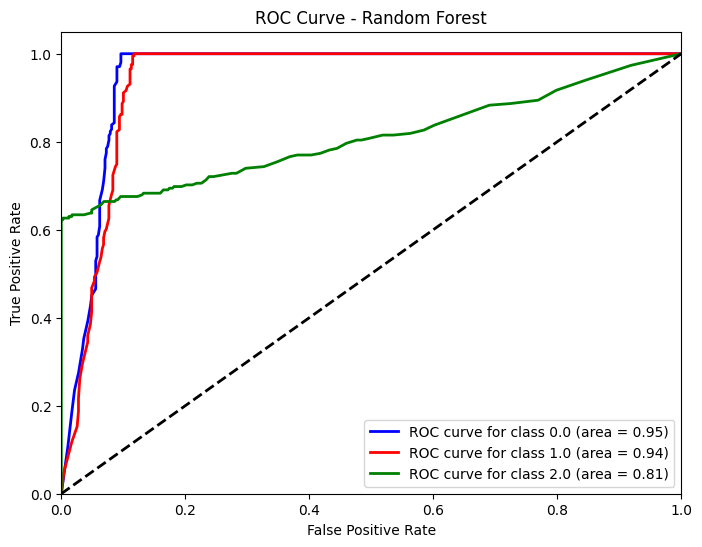

In [ ]:
# 예측 확률 계산
y_score_rf = rf_classifier.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

- XGBClassifier 모델

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# XGBoost 분류기 생성
xgb_classifier = xgb.XGBClassifier(n_estimators=100, random_state=42)

# 훈련 데이터로 모델 학습
xgb_classifier.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred = xgb_classifier.predict(X_test)

# 모델 성능 출력
accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Accuracy: 0.82
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.92      0.87       204
         1.0       0.80      0.88      0.84       203
         2.0       0.82      0.69      0.75       265

    accuracy                           0.82       672
   macro avg       0.82      0.83      0.82       672
weighted avg       0.82      0.82      0.81       672

Confusion Matrix:
 [[188   0  16]
 [  0 179  24]
 [ 38  45 182]]
Precision: 0.82
Recall: 0.82
F1 Score: 0.81
Matthews Correlation Coefficient: 0.73
Threat Score: 2.45


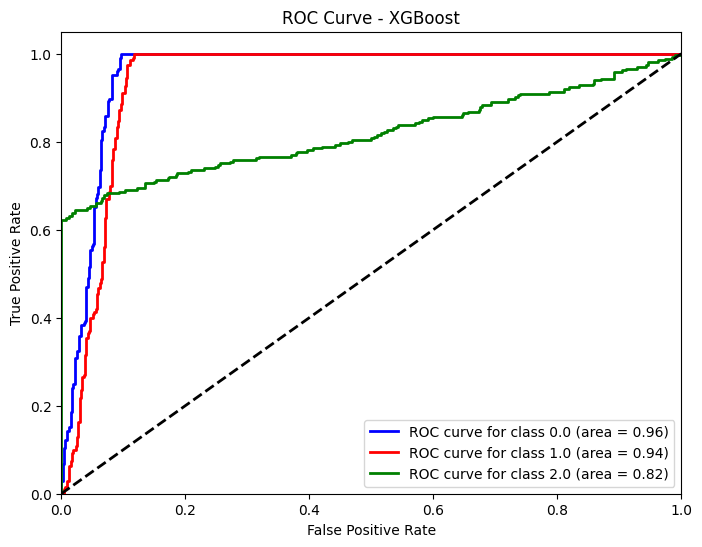

In [ ]:
# 예측 확률 계산
y_score_xgb = xgb_classifier.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.show()

- SVC(서포트 벡터 머신)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# 서포트 벡터 머신 모델 생성
svm_model = SVC(kernel='linear', decision_function_shape='ovr')  # 'ovr'은 One-vs-Rest 방식

# 훈련 데이터로 모델 학습
svm_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred_svm = svm_model.predict(X_test)

accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Accuracy: 0.82
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.92      0.87       204
         1.0       0.80      0.88      0.84       203
         2.0       0.82      0.69      0.75       265

    accuracy                           0.82       672
   macro avg       0.82      0.83      0.82       672
weighted avg       0.82      0.82      0.81       672

Confusion Matrix:
 [[188   0  16]
 [  0 179  24]
 [ 38  45 182]]
Precision: 0.82
Recall: 0.82
F1 Score: 0.81
Matthews Correlation Coefficient: 0.73
Threat Score: 2.45


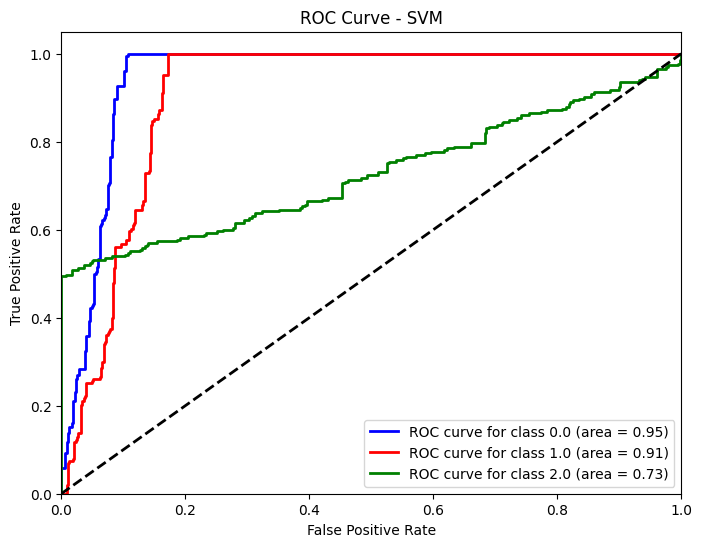

In [ ]:
# 점수 계산 (decision_function)
y_score_svm = svm_model.decision_function(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc="lower right")
plt.show()

- LightGBM 모델

In [ ]:
pip install dask[dataframe]

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 4.7 MB/s eta 0:00:00


In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, matthews_corrcoef

# LightGBM 모델 생성
lgbm_model = lgb.LGBMClassifier(objective='multiclass', num_class=5, force_row_wise=True)

# 훈련 데이터로 모델 학습
lgbm_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred_lgbm = lgbm_model.predict(X_test)

accuracy_score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_score:.2f}")

classification_report = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report)

confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Total Bins 285
[LightGBM] [Info] Number of data points in the train set: 2686, number of used features: 6
[LightGBM] [Info] Start training from score -1.192620
[LightGBM] [Info] Start training from score -1.195077
[LightGBM] [Info] Start training from score -0.931673
Accuracy: 0.82
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.92      0.87       204
         1.0       0.80      0.88      0.84       203
         2.0       0.82      0.69      0.75       265

    accuracy                           0.82       672
   macro avg       0.82      0.83      0.82       672
weighted avg       0.82      0.82      0.81       672

Confusion Matrix:
 [[188   0  16]
 [  0 179  24]
 [ 38  45 182]]
Precision: 0.82
Recall: 0.82
F1 Score: 0.81
Matthews Correlation Coefficient: 0.73
Threat Score: 2.45


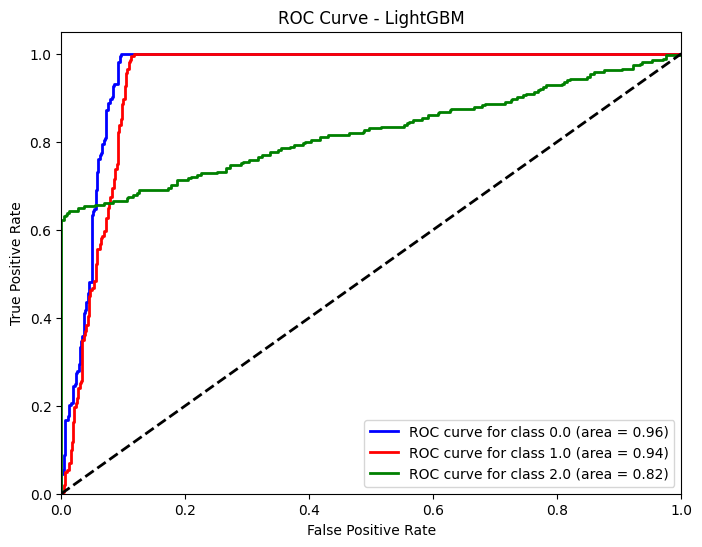

In [ ]:
# 예측 확률 계산
y_score_lgbm = lgbm_model.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_lgbm[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend(loc="lower right")
plt.show()

# 하이퍼파리미터 튜닝(그리드서치)

In [ ]:
import warnings
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

# XGBoost 경고 무시
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')

# XGBoost 분류기 생성
xgb_classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [50, 100, 150, 200],  # 트리 개수
    'max_depth': [3, 6, 10],  # 트리의 최대 깊이
    'learning_rate': [0.01, 0.1, 0.2],  # 학습률
    'subsample': [0.8, 1.0],  # 훈련에 사용할 데이터 샘플 비율
    'colsample_bytree': [0.8, 1.0],  # 각 트리에서 사용할 특성 비율
    'gamma': [0, 0.1, 0.2],  # 리프 노드 분할의 최소 손실 감소
    'min_child_weight': [1, 2]  # 리프 노드의 최소 가중치
}

# 그리드 서치 설정 (verbose=0으로 설정하여 출력 최소화)
grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid, cv=5, n_jobs=1, verbose=0, scoring='accuracy')

# 훈련 데이터로 하이퍼파라미터 튜닝 수행
grid_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print("Best Hyperparameters:", grid_search.best_params_)

# 최적의 모델로 예측
best_xgb_classifier = grid_search.best_estimator_
y_pred = best_xgb_classifier.predict(X_test)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

classification_report_str = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_report_str)

confusion_matrix_result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix_result)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
threat_score = precision + recall + f1

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Matthews Correlation Coefficient: {mcc:.2f}")
print(f"Threat Score: {threat_score:.2f}")

Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 2, 'n_estimators': 50, 'subsample': 1.0}
Accuracy: 0.85
Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      1.00      0.90       204
         1.0       0.79      0.99      0.88       203
         2.0       0.98      0.63      0.76       265

    accuracy                           0.85       672
   macro avg       0.86      0.87      0.85       672
weighted avg       0.87      0.85      0.84       672

Confusion Matrix:
 [[204   0   0]
 [  0 200   3]
 [ 45  54 166]]
Precision: 0.87
Recall: 0.85
F1 Score: 0.84
Matthews Correlation Coefficient: 0.79
Threat Score: 2.56


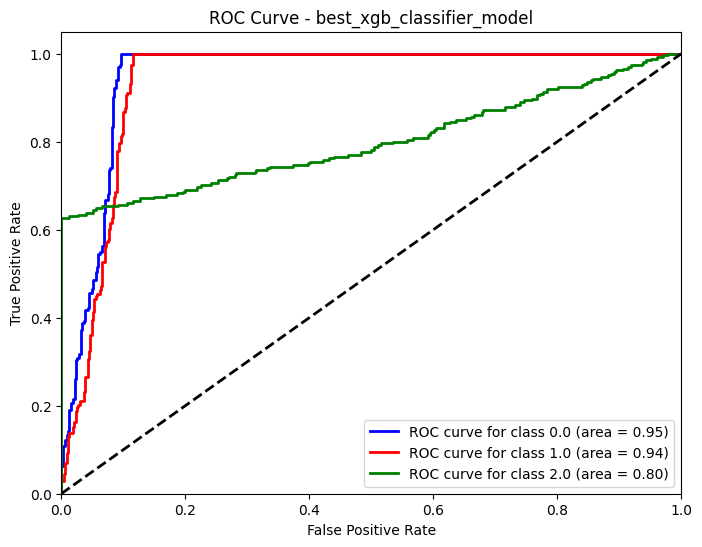

In [ ]:
# 예측 확률 계산
y_score_best = best_xgb_classifier.predict_proba(X_test)

# ROC Curve 및 AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_best
  [:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 시각화
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - best_xgb_classifier_model')
plt.legend(loc="lower right")
plt.show()

- 모델 저장 및 확인

In [ ]:
import pickle

# 그리드 서치에서 최적의 모델을 가져옴
best_xgb_classifier = grid_search.best_estimator_

# 학습된 모델을 Pickle을 사용해 저장
with open('best_xgb_classifier.pkl', 'wb') as f:
    pickle.dump(best_xgb_classifier, f)

print("모델이 'best_xgb_classifier.pkl'로 저장되었습니다.")

모델이 'best_xgb_classifier.pkl'로 저장되었습니다.


In [ ]:
# Pickle을 사용해 저장된 모델 로드
with open('/content/best_xgb_classifier.pkl', 'rb') as f:
    loaded_rf_classifier = pickle.load(f)

# 로드된 모델로 예측
y_pred = loaded_rf_classifier.predict(X_test)
print("모델이 성공적으로 불러와졌습니다.")

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

모델이 성공적으로 불러와졌습니다.
Accuracy: 0.85


# 변수 중요도 및 SHAP

In [ ]:
!pip install shap

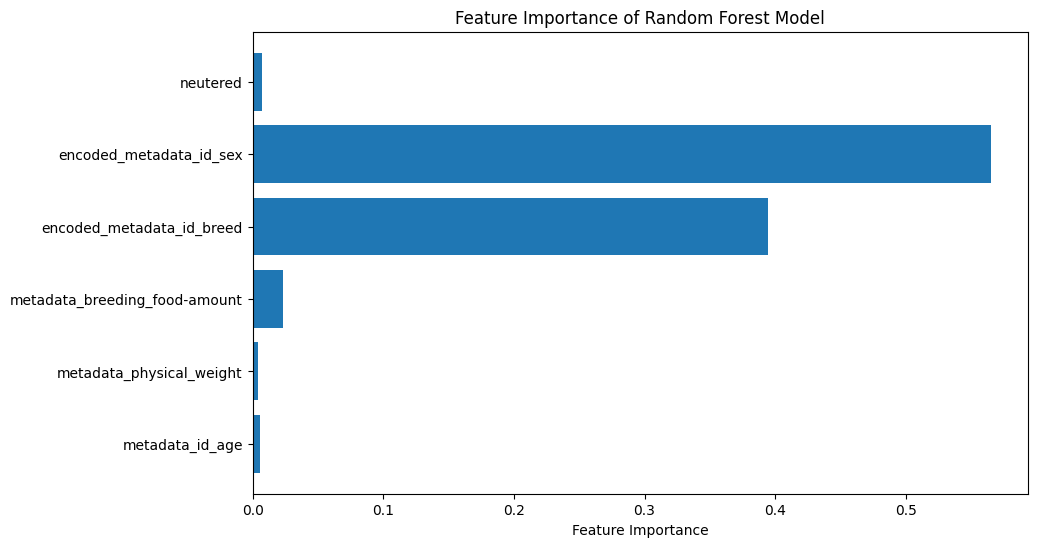

In [ ]:
import matplotlib.pyplot as plt

# 변수 중요도 출력
feature_importances = best_xgb_classifier.feature_importances_

# 변수 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance of Random Forest Model')
plt.show()

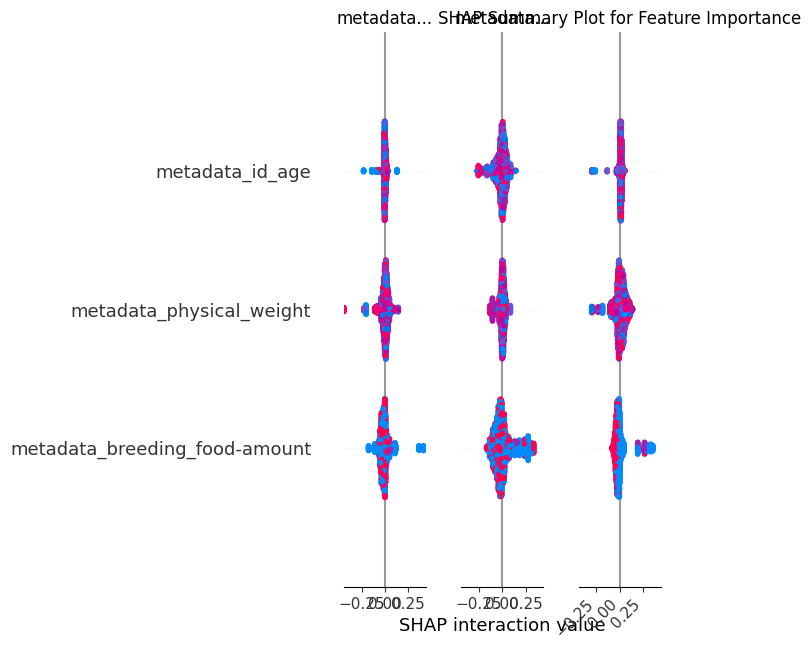

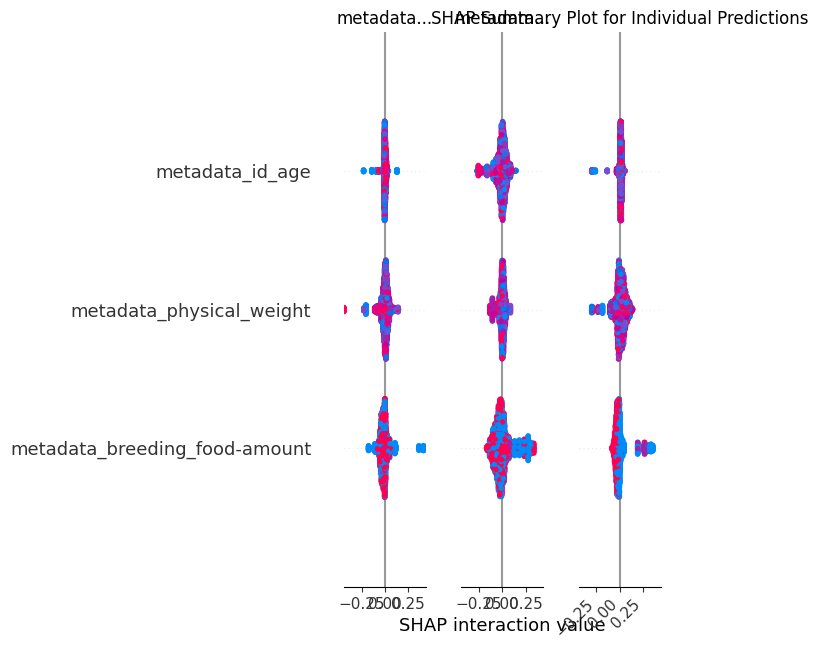

In [ ]:
import shap
import matplotlib.pyplot as plt

# SHAP TreeExplainer 생성 (RandomForest 모델에 적합)
explainer = shap.TreeExplainer(best_xgb_classifier)

# SHAP 값을 계산
shap_values = explainer.shap_values(X_train)

# Summary Plot (bar plot)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title('SHAP Summary Plot for Feature Importance')

# x축의 간격을 늘리기 위해 xticks 설정
plt.xticks(rotation=45, ha="right")  # x축 레이블 각도 조정 (필요시 추가)
plt.tight_layout()  # 그래프 요소들이 겹치지 않도록 조정
plt.show()

# Summary Plot (dot plot)
shap.summary_plot(shap_values, X_train, show=False)
plt.title('SHAP Summary Plot for Individual Predictions')

# x축 간격을 늘리기 위해 xticks 설정
plt.xticks(rotation=45, ha="right")  # x축 레이블 각도 조정 (필요시 추가)
plt.tight_layout()  # 그래프 요소들이 겹치지 않도록 조정
plt.show()

# class 2번(정상, Normal)에 대해서 분류를 잘 하지 못하는 이유에 대한 분석

In [ ]:
df['metadata_medical_diseaseName'].value_counts()

,count
metadata_medical_diseaseName,
Normal,1323
DER/RES,1019
GAS,1016


- 혼동 행렬

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[204   0   0]
 [  0 200   3]
 [ 45  54 166]]


- 변수 중요도

In [ ]:
import pandas as pd

# Feature Importance 출력
feature_importances = best_xgb_classifier.feature_importances_
feature_names = X_train.columns  # X_train의 컬럼명이 feature names라 가정
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                         Feature  Importance
4        encoded_metadata_id_sex    0.564933
3      encoded_metadata_id_breed    0.394774
2  metadata_breeding_food-amount    0.023439
5                       neutered    0.006965
0                metadata_id_age    0.005600
1       metadata_physical_weight    0.004289


- 학습 곡선

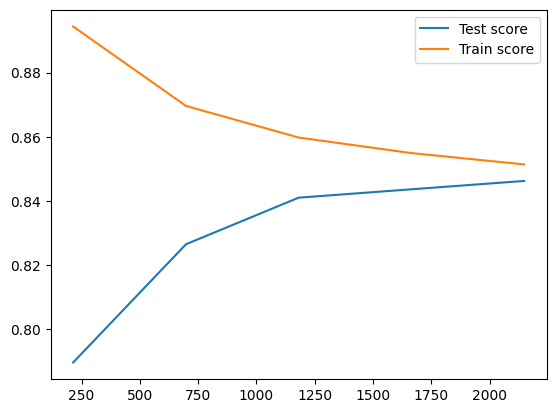

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(best_xgb_classifier, X_train, y_train)
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test score")
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train score")
plt.legend()
plt.show()

- 열들 간의 관계 시각화
  - 열들 간의 명확한 차이가 보이지 않아서 2번 클래스에 대한 것은 분류를 잘 하지 못하는 것 같음

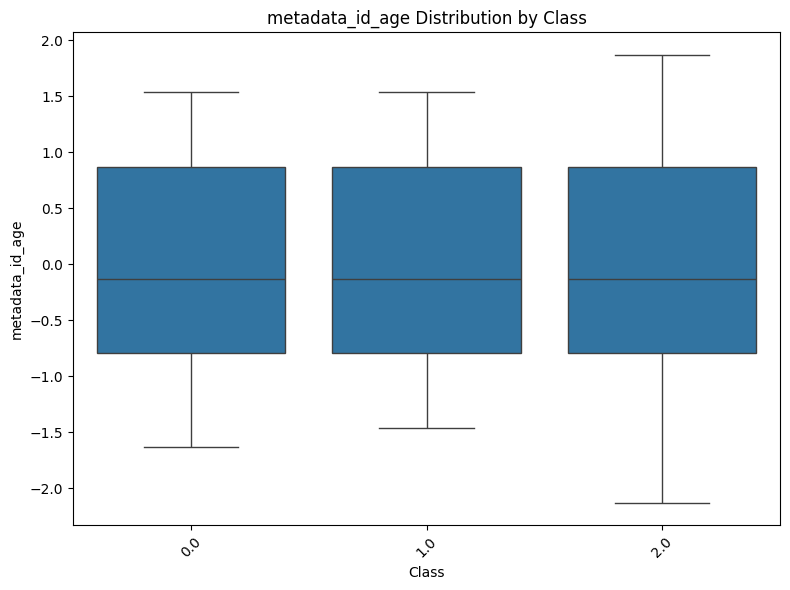

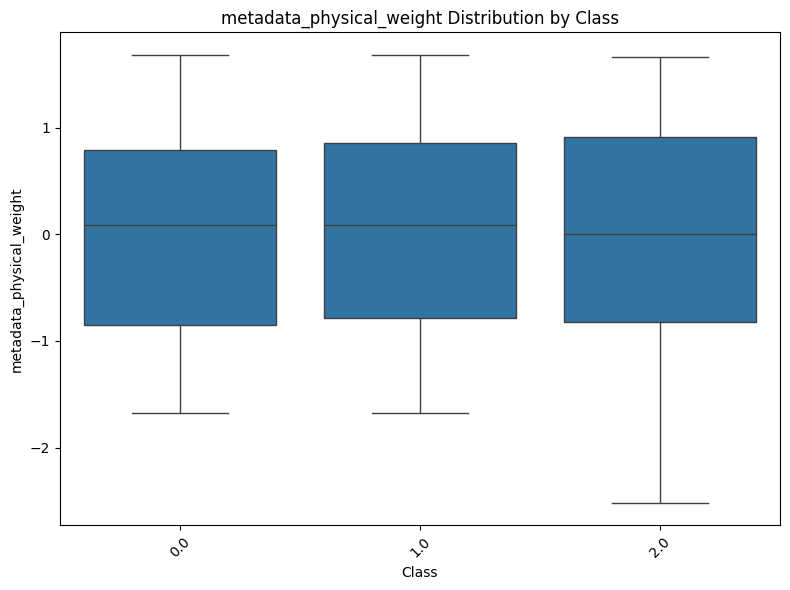

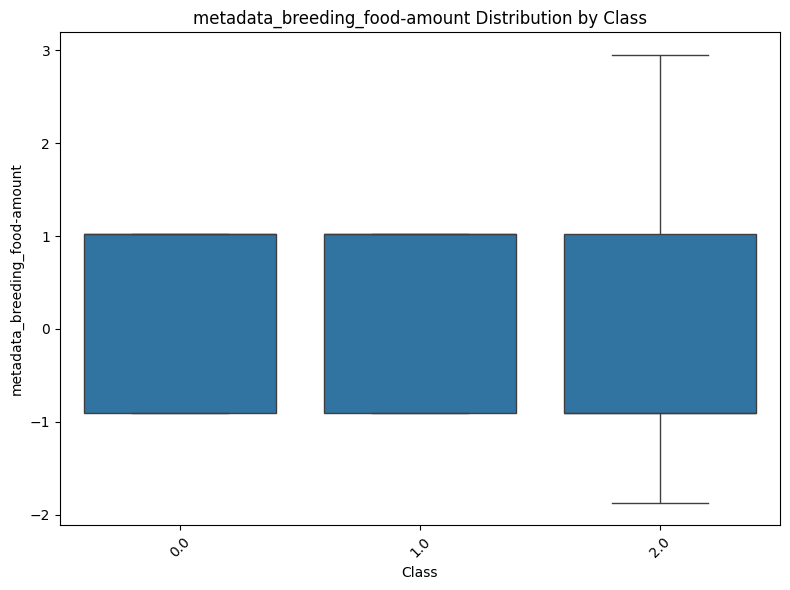

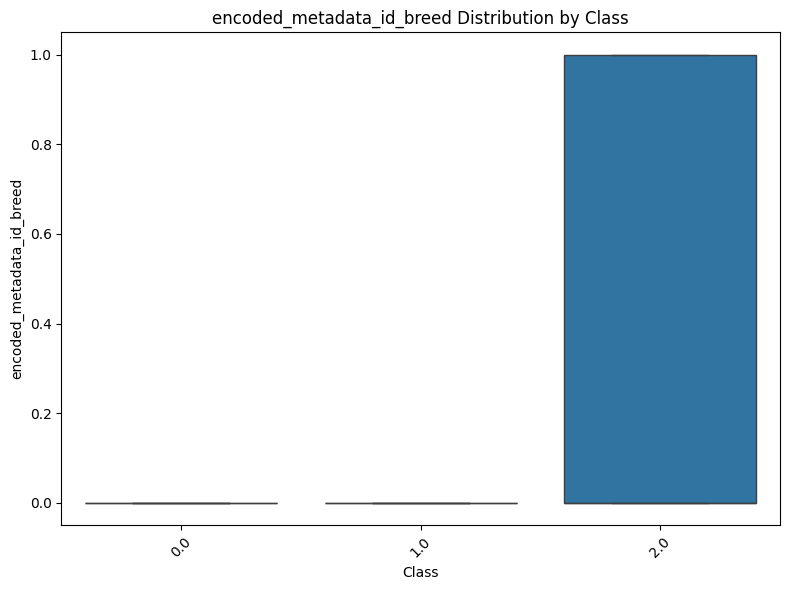

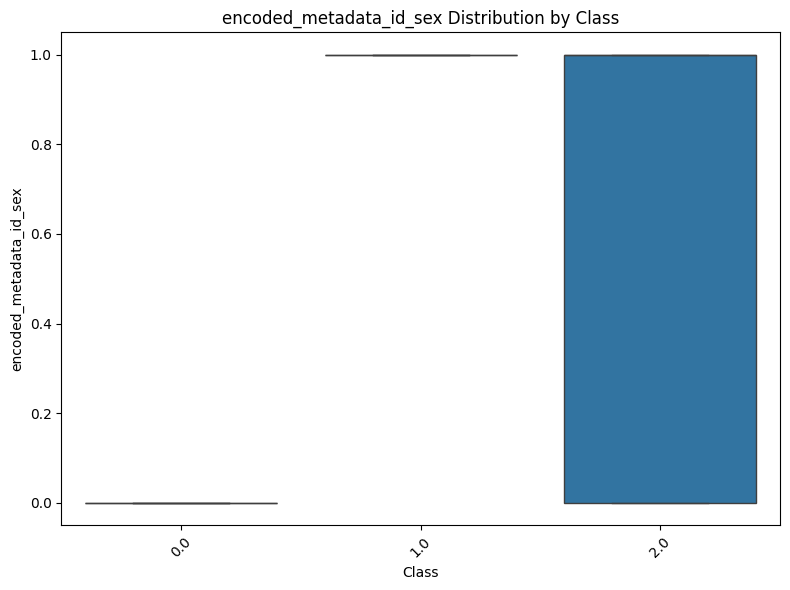

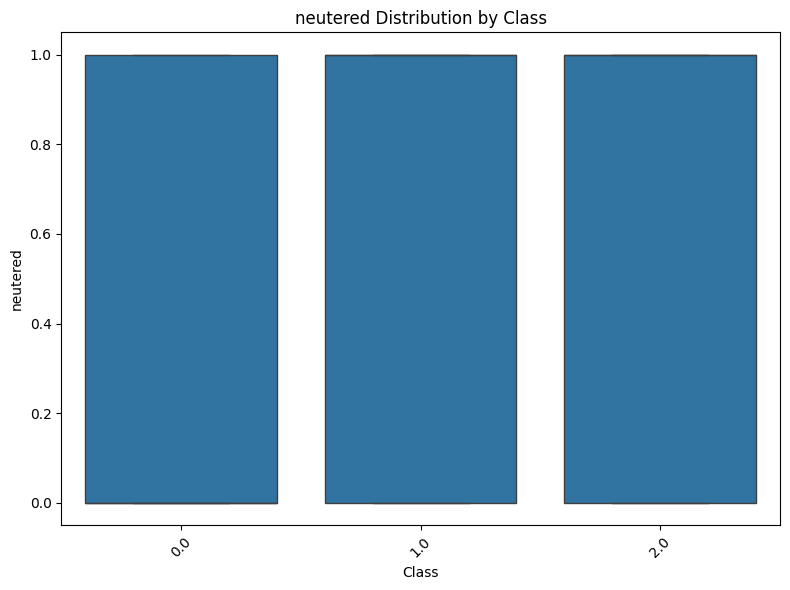

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 클래스별 분포를 확인할 변수 리스트
variables = X_train.columns  # X_train에 있는 모든 변수 사용

# 변수별로 박스플롯 생성
for variable in variables:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=X_train, x=y_train, y=variable)
    plt.title(f'{variable} Distribution by Class')
    plt.xlabel('Class')
    plt.ylabel(variable)
    plt.xticks(rotation=45)  # 클래스 이름이 긴 경우 글씨를 기울임
    plt.tight_layout()
    plt.show()

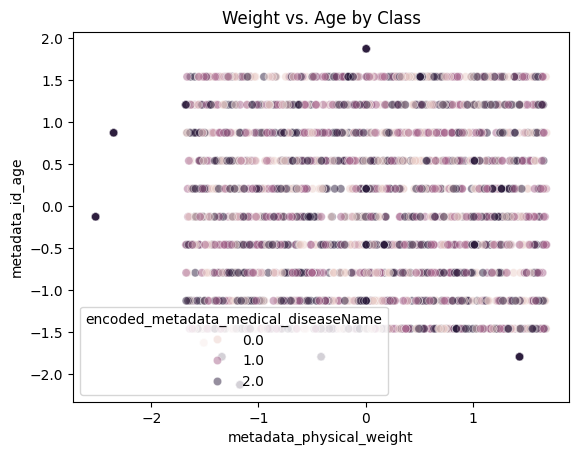

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=X_train,
    x='metadata_physical_weight',
    y='metadata_id_age',
    hue=y_train,
    alpha=0.5
)
plt.title('Weight vs. Age by Class')
plt.show()

- pca 후 시각화

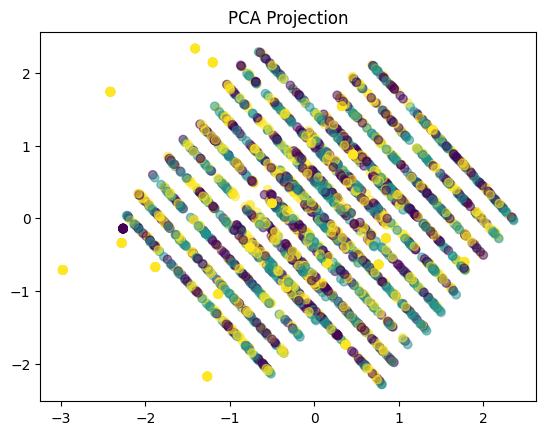

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.5)
plt.title('PCA Projection')
plt.show()

- t-SNE를 이용한 비선형 차원 축소

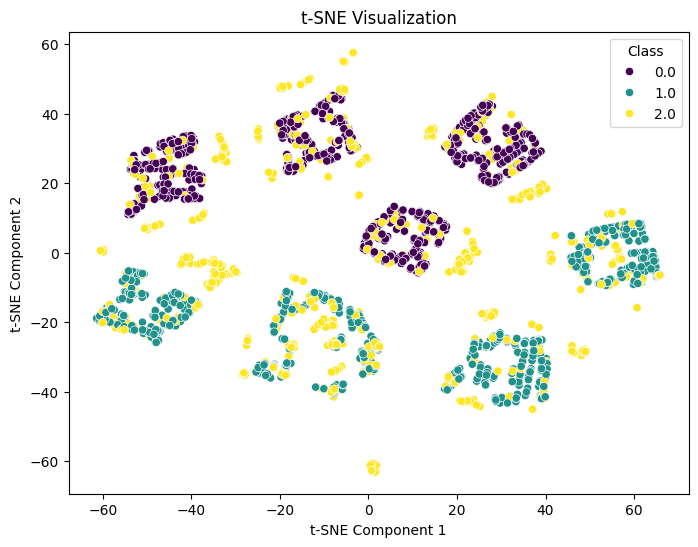

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# t-SNE 적용
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train)

# t-SNE 결과 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_train, palette='viridis')
plt.title('t-SNE Visualization')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Class')
plt.show()

- 2. UMAP를 이용한 비선형 차원 축소

In [ ]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.0 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


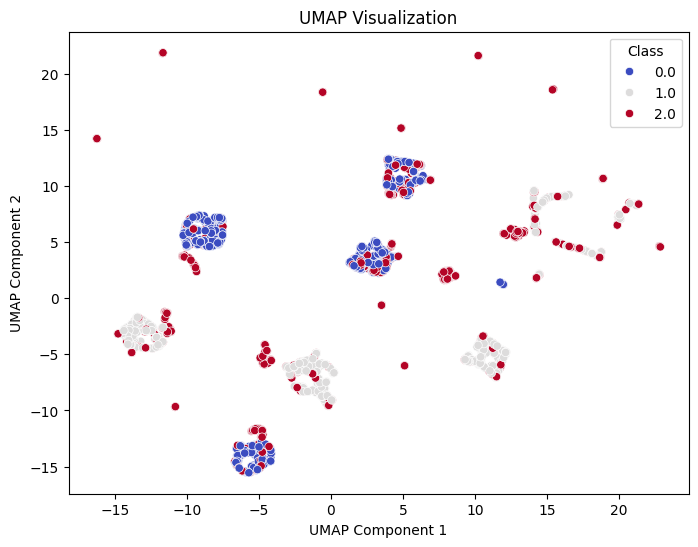

In [ ]:
import umap

# UMAP 적용
umap_model = umap.UMAP(n_neighbors=15, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_train)

# UMAP 결과 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_train, palette='coolwarm')
plt.title('UMAP Visualization')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend(title='Class')
plt.show()

# 결론
  - 정상인 것들은 대부분 다른 질병 코드의 특징들과 유사하게 몰려있기 때문에 잘 분류하지 못하는 것 같음 이것은 추후에 다른 모델을 사용해서 잘 해결해야 할 것